In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

df = pd.read_csv("task1_outputs/salary_task1_v1_processed.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

Dataset Loaded Successfully!
Shape: (2000, 19)


In [2]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Variables:")
print(numeric_cols)

Numerical Variables:
['age', 'experience_years', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'salary_bdt', 'recent_project_description_length', 'survey_year', 'survey_month', 'role_seniority_encoded']


In [3]:
pearson_corr = df[numeric_cols].corr(method="pearson")

print("Pearson Correlation:")
display(pearson_corr)

Pearson Correlation:


,age,experience_years,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_year,survey_month,role_seniority_encoded
age,1.000000,0.897403,-0.014076,-0.029914,-0.031376,-0.016161,0.765101,-0.001609,0.009419,-0.007613,-0.016215
experience_years,0.897403,1.000000,-0.029473,-0.034220,-0.035850,-0.019748,0.790920,-0.006252,-0.010257,-0.002552,-0.016453
skills_count,-0.014076,-0.029473,1.000000,-0.014082,-0.011268,-0.003196,0.036010,-0.003326,0.006453,0.053423,0.002111
certifications,-0.029914,-0.034220,-0.014082,1.000000,0.044084,0.003018,0.014655,0.023790,0.041349,-0.018110,-0.014203
worked_remote,-0.031376,-0.035850,-0.011268,0.044084,1.000000,-0.022935,0.011874,0.007903,-0.009266,-0.023563,0.032158
last_promotion_years_ago,-0.016161,-0.019748,-0.003196,0.003018,-0.022935,1.000000,-0.014864,-0.028167,-0.006140,-0.015411,0.024523
salary_bdt,0.765101,0.790920,0.036010,0.014655,0.011874,-0.014864,1.000000,-0.015021,0.001070,-0.007387,0.194582
recent_project_description_length,-0.001609,-0.006252,-0.003326,0.023790,0.007903,-0.028167,-0.015021,1.000000,-0.014697,-0.001344,0.009693
survey_year,0.009419,-0.010257,0.006453,0.041349,-0.009266,-0.006140,0.001070,-0.014697,1.000000,-0.031658,-0.000392
survey_month,-0.007613,-0.002552,0.053423,-0.018110,-0.023563,-0.015411,-0.007387,-0.001344,-0.031658,1.000000,-0.000013


In [4]:
spearman_corr = df[numeric_cols].corr(method="spearman")

print("Spearman Correlation:")
display(spearman_corr)

Spearman Correlation:


,age,experience_years,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_year,survey_month,role_seniority_encoded
age,1.000000,0.893812,-0.012696,-0.032806,-0.024835,-0.009857,0.842821,0.006921,0.014455,-0.015069,-0.013933
experience_years,0.893812,1.000000,-0.018872,-0.032796,-0.029699,-0.019234,0.870419,0.003554,-0.009653,-0.010355,-0.025829
skills_count,-0.012696,-0.018872,1.000000,-0.013978,-0.020584,-0.008614,0.044986,-0.000264,0.008154,0.045514,0.003378
certifications,-0.032806,-0.032796,-0.013978,1.000000,0.038437,0.002171,0.006813,0.033831,0.035953,-0.012522,0.006574
worked_remote,-0.024835,-0.029699,-0.020584,0.038437,1.000000,-0.025931,0.017526,0.010029,-0.009266,-0.023725,0.024355
last_promotion_years_ago,-0.009857,-0.019234,-0.008614,0.002171,-0.025931,1.000000,0.001128,-0.021689,-0.007474,-0.022450,0.034772
salary_bdt,0.842821,0.870419,0.044986,0.006813,0.017526,0.001128,1.000000,0.003554,0.002947,-0.004385,0.192736
recent_project_description_length,0.006921,0.003554,-0.000264,0.033831,0.010029,-0.021689,0.003554,1.000000,-0.015632,-0.005804,0.001560
survey_year,0.014455,-0.009653,0.008154,0.035953,-0.009266,-0.007474,0.002947,-0.015632,1.000000,-0.031581,-0.006268
survey_month,-0.015069,-0.010355,0.045514,-0.012522,-0.023725,-0.022450,-0.004385,-0.005804,-0.031581,1.000000,-0.002128


In [5]:
pearson_p = pd.DataFrame(
    index=numeric_cols,
    columns=numeric_cols,
    dtype=float
)

spearman_p = pd.DataFrame(
    index=numeric_cols,
    columns=numeric_cols,
    dtype=float
)

for col1 in numeric_cols:
    for col2 in numeric_cols:

        _, p1 = pearsonr(df[col1], df[col2])
        _, p2 = spearmanr(df[col1], df[col2])

        pearson_p.loc[col1, col2] = p1
        spearman_p.loc[col1, col2] = p2

print("P-values calculated successfully.")

P-values calculated successfully.


In [6]:
from statsmodels.stats.multitest import multipletests

def significant_matrix(p_matrix, alpha=0.05):

    cols = p_matrix.columns
    result = pd.DataFrame(
        False,
        index=cols,
        columns=cols
    )

    pairs = []
    p_values = []

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):

            pairs.append((cols[i], cols[j]))
            p_values.append(p_matrix.iloc[i, j])

    reject, _, _, _ = multipletests(
        p_values,
        alpha=alpha,
        method="fdr_bh"
    )

    for (c1, c2), sig in zip(pairs, reject):

        result.loc[c1, c2] = sig
        result.loc[c2, c1] = sig

    return result


pearson_significant = significant_matrix(pearson_p)
spearman_significant = significant_matrix(spearman_p)

In [7]:
pearson_sig = pearson_corr.where(
    pearson_significant,
    0
)

spearman_sig = spearman_corr.where(
    spearman_significant,
    0
)

In [8]:
def plot_heatmap(matrix, title):

    plt.figure(figsize=(12, 9))

    plt.imshow(matrix)

    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=75
    )

    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )

    plt.title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):

            value = matrix.iloc[i, j]

            if value != 0:
                plt.text(
                    j, i,
                    f"{value:.2f}",
                    ha="center",
                    va="center"
                )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

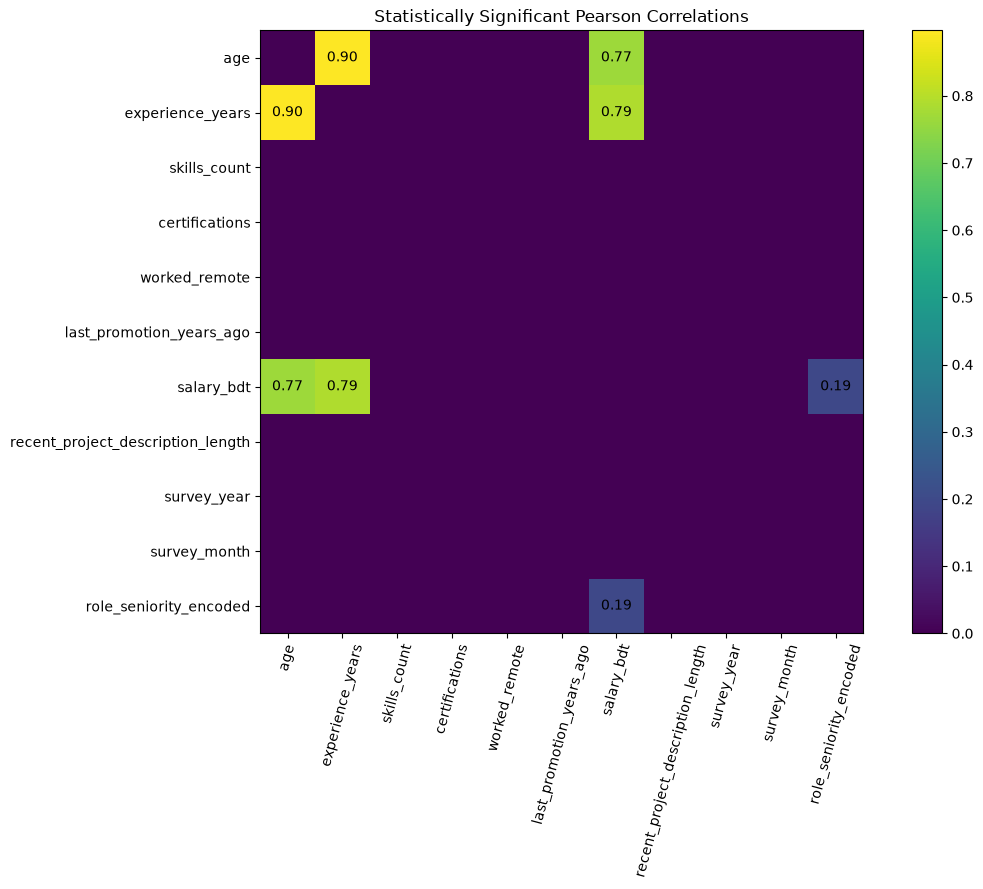

In [9]:
plot_heatmap(
    pearson_sig,
    "Statistically Significant Pearson Correlations"
)

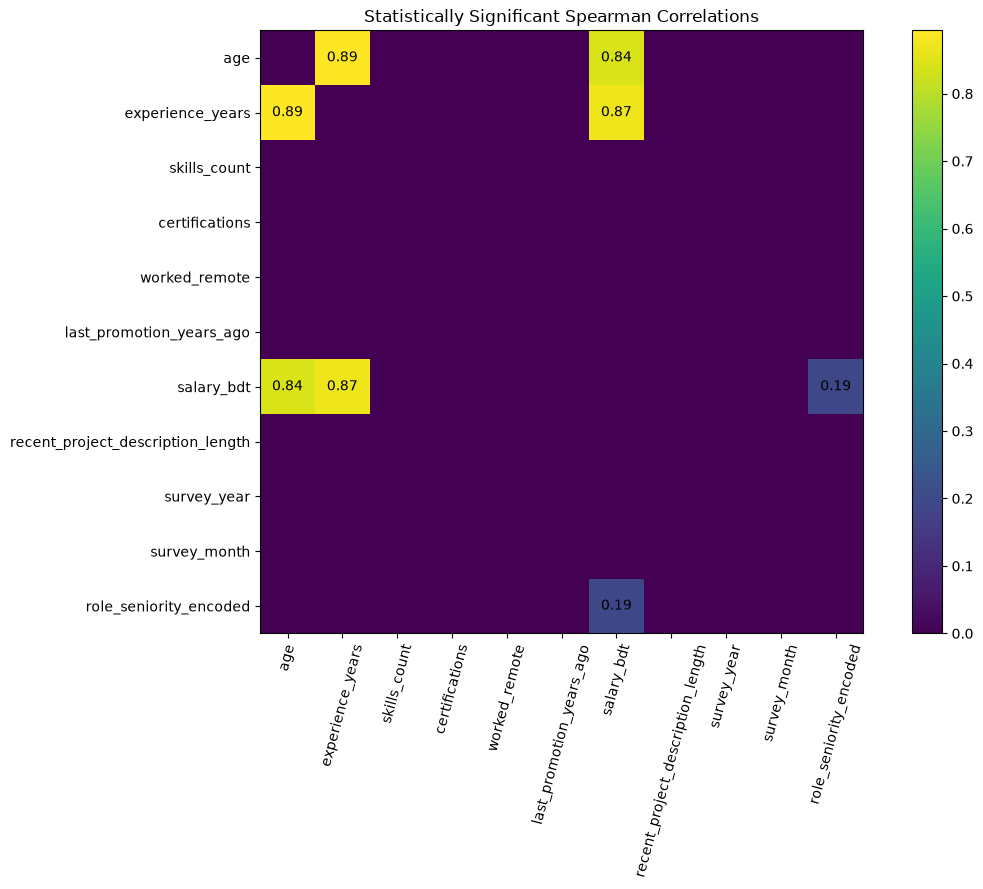

In [10]:
plot_heatmap(
    spearman_sig,
    "Statistically Significant Spearman Correlations"
)

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select predictor variables
vif_columns = [
    col for col in numeric_cols
    if col not in [
        "salary_bdt",
        "survey_year",
        "survey_month"
    ]
]

# Create predictor dataframe
X = df[vif_columns].copy()

# Calculate VIF
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Sort from highest to lowest VIF
vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
).reset_index(drop=True)

print("===== VIF REPORT =====")
display(vif_data)

===== VIF REPORT =====


,Feature,VIF
0,age,60.825080
1,recent_project_description_length,30.255235
2,experience_years,9.248221
3,skills_count,6.540272
4,last_promotion_years_ago,2.200921
5,role_seniority_encoded,2.162550
6,certifications,2.062814
7,worked_remote,1.625898


In [14]:
from pathlib import Path

# Create output folder if it doesn't exist
output_dir = Path("task3_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Save VIF report
vif_data.to_csv(
    output_dir / "task3_vif_report.csv",
    index=False
)

print("VIF report saved successfully!")
print("Location:", output_dir / "task3_vif_report.csv")

VIF report saved successfully!
Location: task3_outputs\task3_vif_report.csv


In [16]:
from pathlib import Path

output_dir = Path("task3_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

In [17]:
vif_data.to_csv(
    output_dir / "task3_vif_report.csv",
    index=False
)

print("VIF report saved successfully!")

VIF report saved successfully!
